# Ski Pass Price Exploratory Data Analysis

This notebook explores historical ski pass pricing data from 2008-2026.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

df = pd.read_csv('/media/kwierman/Data/powderpipeline/pass_prices.csv')

#def fix_season_year(val):
#    match = re.match(r'^(\d{4})-(\d{2})$', str(val))
#    if match:
#        return f"{match.group(1)}-12-01"
#    return val

#df['datetime scraped'] = df['datetime scraped'].apply(fix_season_year)
df['datetime scraped'] = pd.to_datetime(df['datetime scraped'], format='mixed')
df.tail()

,uuid,datetime scraped,pass provider,pass name,age range,price_usd,season years,notes
312,max-pass-2021-22-adult,2024-10-20 14:00:00+00:00,MAX Pass,MAX Pass,Adult,729,2021-22,+$30
313,max-pass-2022-23-adult,2024-10-20 14:00:00+00:00,MAX Pass,MAX Pass,Adult,759,2022-23,+$30
314,max-pass-2023-24-adult,2024-10-20 14:00:00+00:00,MAX Pass,MAX Pass,Adult,799,2023-24,+$40
315,max-pass-2024-25-adult,2024-10-20 14:00:00+00:00,MAX Pass,MAX Pass,Adult,849,2024-25,+$50
316,max-pass-2025-26-adult,2024-10-20 14:00:00+00:00,MAX Pass,MAX Pass,Adult,899,2025-26,+$50


In [2]:
# Parse season years into start year (numeric)
df['season_start_year'] = df['season years'].str.extract(r'^(\d{4})').astype(int)

# Create a clean pass identifier
df['pass_label'] = df['pass provider'] + ' - ' + df['pass name'] + ' (' + df['age range'] + ')'

print(f"Dataset shape: {df.shape}")
print(f"\nDate range: {df['season_start_year'].min()} - {df['season_start_year'].max()}")
print(f"\nPass providers: {df['pass provider'].unique()}")
print(f"\nUnique passes: {df['pass name'].nunique()}")

Dataset shape: (317, 10)

Date range: 2008 - 2026

Pass providers: <ArrowStringArray>
[          'Epic Pass',           'Ikon Pass', 'Mountain Collective',
           'Indy Pass',      'Aspen Snowmass',        'Jackson Hole',
     'Powder Alliance',            'MAX Pass']
Length: 8, dtype: str

Unique passes: 14


In [3]:
# Summary statistics
df.describe()

,price_usd,season_start_year
count,317.000000,317.000000
mean,586.312303,2019.876972
std,449.355551,3.724789
min,89.000000,2008.000000
25%,310.000000,2017.000000
50%,469.000000,2020.000000
75%,689.000000,2023.000000
max,2699.000000,2026.000000


In [4]:
# Focus on Adult full/unlimited passes for main comparison
adult_passes = df[df['age range'] == 'Adult'].copy()

# Create pass category for easier plotting
def categorize_pass(row):
    name = row['pass name'].lower()
    provider = row['pass provider']
    if 'epic pass' == name and 'epic local' not in name.lower():
        return 'Epic Pass'
    elif 'epic local' in name.lower():
        return 'Epic Local'
    elif 'ikon pass' == name:
        return 'Ikon Pass'
    elif 'ikon base' in name.lower():
        return 'Ikon Base'
    elif 'ikon session' in name.lower():
        return 'Ikon Session'
    elif 'mountain collective' in name.lower():
        return 'Mountain Collective'
    elif 'indy pass' == name or 'indy+' in name.lower():
        return 'Indy Pass'
    elif 'aspen' in name.lower() or 'premier' in name.lower():
        return 'Aspen Premier'
    elif 'jackson' in name.lower() or 'grand' in name.lower():
        return 'Jackson Hole'
    elif 'powder' in name.lower():
        return 'Powder Alliance'
    elif 'max' in name.lower():
        return 'MAX Pass'
    else:
        return provider

adult_passes['category'] = adult_passes.apply(categorize_pass, axis=1)
print(adult_passes['category'].value_counts())

category
Epic Pass              40
Mountain Collective    14
Aspen Premier          14
Epic Local             13
Indy Pass              13
Jackson Hole           11
Ikon Pass               9
Powder Alliance         9
MAX Pass                9
Ikon Base               8
Ikon Session            6
Name: count, dtype: int64


## Pass Price Over Time

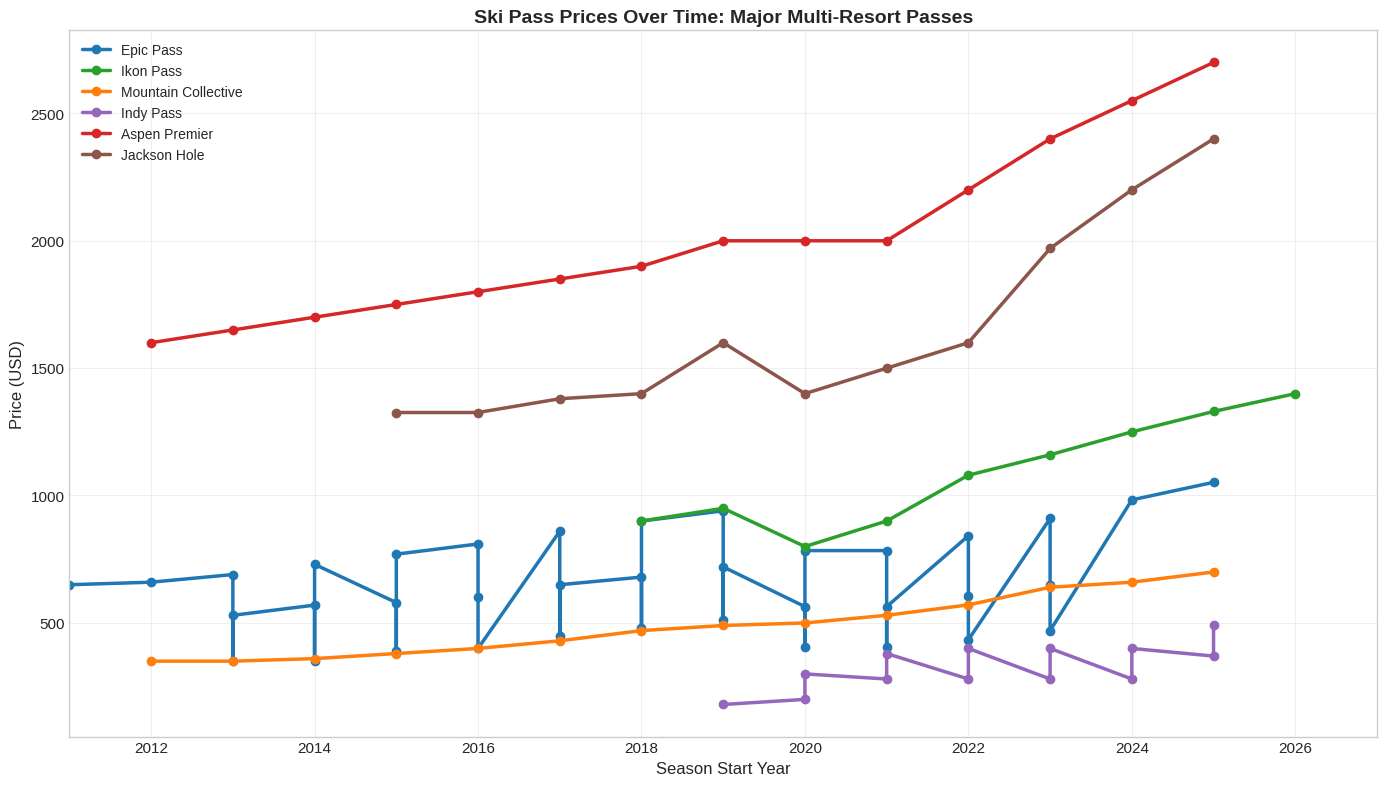

In [5]:
# Main price trends - Adult passes only
fig, ax = plt.subplots(figsize=(14, 8))

key_passes = ['Epic Pass', 'Ikon Pass', 'Mountain Collective', 'Indy Pass', 'Aspen Premier', 'Jackson Hole']
colors = {'Epic Pass': '#1f77b4', 'Ikon Pass': '#2ca02c', 'Mountain Collective': '#ff7f0e', 
          'Indy Pass': '#9467bd', 'Aspen Premier': '#d62728', 'Jackson Hole': '#8c564b'}

for pass_cat in key_passes:
    pass_data = adult_passes[adult_passes['category'] == pass_cat].sort_values('season_start_year')
    if len(pass_data) > 0:
        ax.plot(pass_data['season_start_year'], pass_data['price_usd'], 
                marker='o', linewidth=2.5, markersize=6,
                label=pass_cat, color=colors.get(pass_cat, None))

ax.set_xlabel('Season Start Year', fontsize=12)
ax.set_ylabel('Price (USD)', fontsize=12)
ax.set_title('Ski Pass Prices Over Time: Major Multi-Resort Passes', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.set_xlim(2011, 2027)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pass_prices_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

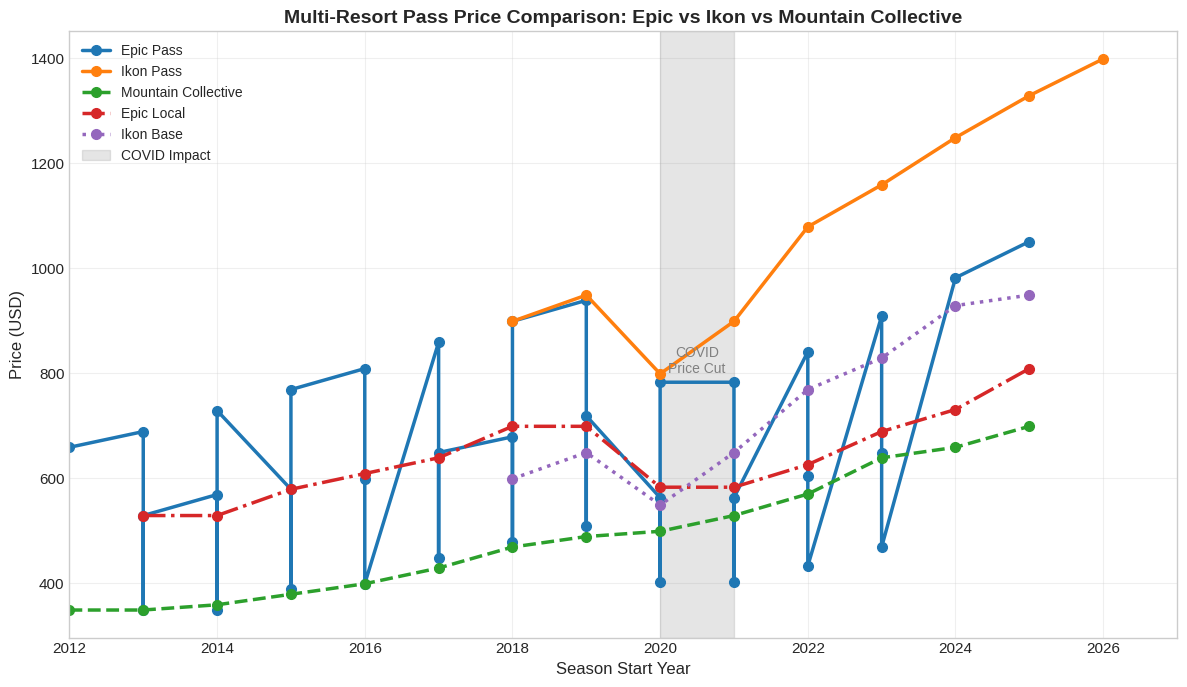

In [6]:
# Zoom in on competitive multi-resort passes
fig, ax = plt.subplots(figsize=(12, 7))

competitive_passes = ['Epic Pass', 'Ikon Pass', 'Mountain Collective', 'Epic Local', 'Ikon Base']
linestyles = {'Epic Pass': '-', 'Ikon Pass': '-', 'Mountain Collective': '--', 
              'Epic Local': '-.', 'Ikon Base': ':'}

for pass_cat in competitive_passes:
    pass_data = adult_passes[adult_passes['category'] == pass_cat].sort_values('season_start_year')
    if len(pass_data) > 0:
        ax.plot(pass_data['season_start_year'], pass_data['price_usd'], 
                marker='o', linewidth=2.5, markersize=7,
                label=pass_cat, linestyle=linestyles.get(pass_cat, '-'))

# Add COVID annotation
ax.axvspan(2020, 2021, alpha=0.2, color='gray', label='COVID Impact')
ax.annotate('COVID\nPrice Cut', xy=(2020.5, 800), fontsize=10, ha='center', color='gray')

ax.set_xlabel('Season Start Year', fontsize=12)
ax.set_ylabel('Price (USD)', fontsize=12)
ax.set_title('Multi-Resort Pass Price Comparison: Epic vs Ikon vs Mountain Collective', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.set_xlim(2012, 2027)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('competitive_pass_prices.png', dpi=150, bbox_inches='tight')
plt.show()

## Price Increase Analysis

In [7]:
# Calculate year-over-year price increases
def calculate_yoy_increase(df_subset):
    df_sorted = df_subset.sort_values('season_start_year').copy()
    df_sorted['prev_price'] = df_sorted['price_usd'].shift(1)
    df_sorted['yoy_change'] = df_sorted['price_usd'] - df_sorted['prev_price']
    df_sorted['yoy_pct'] = (df_sorted['yoy_change'] / df_sorted['prev_price'] * 100).round(1)
    return df_sorted

# Calculate for major passes
epic_full = calculate_yoy_increase(adult_passes[adult_passes['category'] == 'Epic Pass'])
ikon_full = calculate_yoy_increase(adult_passes[adult_passes['category'] == 'Ikon Pass'])
mc_full = calculate_yoy_increase(adult_passes[adult_passes['category'] == 'Mountain Collective'])

# Display YoY changes
print("Epic Pass Year-over-Year Price Changes:")
print(epic_full[['season years', 'price_usd', 'yoy_change', 'yoy_pct']].dropna())

print("\nIkon Pass Year-over-Year Price Changes:")
print(ikon_full[['season years', 'price_usd', 'yoy_change', 'yoy_pct']].dropna())

Epic Pass Year-over-Year Price Changes:
    season years  price_usd  yoy_change  yoy_pct
1        2009-10        599        20.0      3.5
2        2010-11        599         0.0      0.0
3        2011-12        649        50.0      8.3
4        2012-13        659        10.0      1.5
5        2013-14        689        30.0      4.6
88       2013-14        349      -340.0    -49.3
66       2013-14        529       180.0     51.6
68       2014-15        569        40.0      7.6
90       2014-15        349      -220.0    -38.7
7        2014-15        729       380.0    108.9
70       2015-16        579      -150.0    -20.6
92       2015-16        389      -190.0    -32.8
9        2015-16        769       380.0     97.7
11       2016-17        809        40.0      5.2
72       2016-17        599      -210.0    -26.0
94       2016-17        399      -200.0    -33.4
13       2017-18        859       460.0    115.3
96       2017-18        449      -410.0    -47.7
74       2017-18        649  

In [8]:
# Calculate total price increase from launch to latest
def total_increase(df_subset, label):
    first_price = df_subset.iloc[0]['price_usd']
    latest_price = df_subset.iloc[-1]['price_usd']
    years = df_subset.iloc[-1]['season_start_year'] - df_subset.iloc[0]['season_start_year']
    total_pct = ((latest_price - first_price) / first_price * 100).round(1)
    cagr = (((latest_price / first_price) ** (1/years)) - 1) * 100
    print(f"{label}:")
    print(f"  Launch: ${first_price} ({df_subset.iloc[0]['season years']})")
    print(f"  Latest: ${latest_price} ({df_subset.iloc[-1]['season years']})")
    print(f"  Total Increase: {total_pct}%")
    print(f"  CAGR: {cagr:.2f}% per year")
    print()

print("="*60)
print("Total Price Increase Analysis (Adult Passes)")
print("="*60 + "\n")

for pass_cat in ['Epic Pass', 'Ikon Pass', 'Mountain Collective', 'Indy Pass', 'Epic Local', 'Ikon Base', 'Aspen Premier', 'Jackson Hole']:
    pass_data = adult_passes[adult_passes['category'] == pass_cat].sort_values('season_start_year')
    if len(pass_data) >= 2:
        total_increase(pass_data, pass_cat)

Total Price Increase Analysis (Adult Passes)

Epic Pass:
  Launch: $579 (2008-09)
  Latest: $1051 (2025-26)
  Total Increase: 81.5%
  CAGR: 3.57% per year

Ikon Pass:
  Launch: $899 (2018-19)
  Latest: $1399 (2026-27)
  Total Increase: 55.6%
  CAGR: 5.68% per year

Mountain Collective:
  Launch: $349 (2012-13)
  Latest: $699 (2025-26)
  Total Increase: 100.3%
  CAGR: 5.49% per year

Indy Pass:
  Launch: $179 (2019-20)
  Latest: $489 (2025-26)
  Total Increase: 173.2%
  CAGR: 18.23% per year

Epic Local:
  Launch: $529 (2013-14)
  Latest: $809 (2025-26)
  Total Increase: 52.9%
  CAGR: 3.60% per year

Ikon Base:
  Launch: $599 (2018-19)
  Latest: $949 (2025-26)
  Total Increase: 58.4%
  CAGR: 6.79% per year

Aspen Premier:
  Launch: $1599 (2012-13)
  Latest: $2699 (2025-26)
  Total Increase: 68.8%
  CAGR: 4.11% per year

Jackson Hole:
  Launch: $1325 (2015-16)
  Latest: $2399 (2025-26)
  Total Increase: 81.1%
  CAGR: 6.12% per year



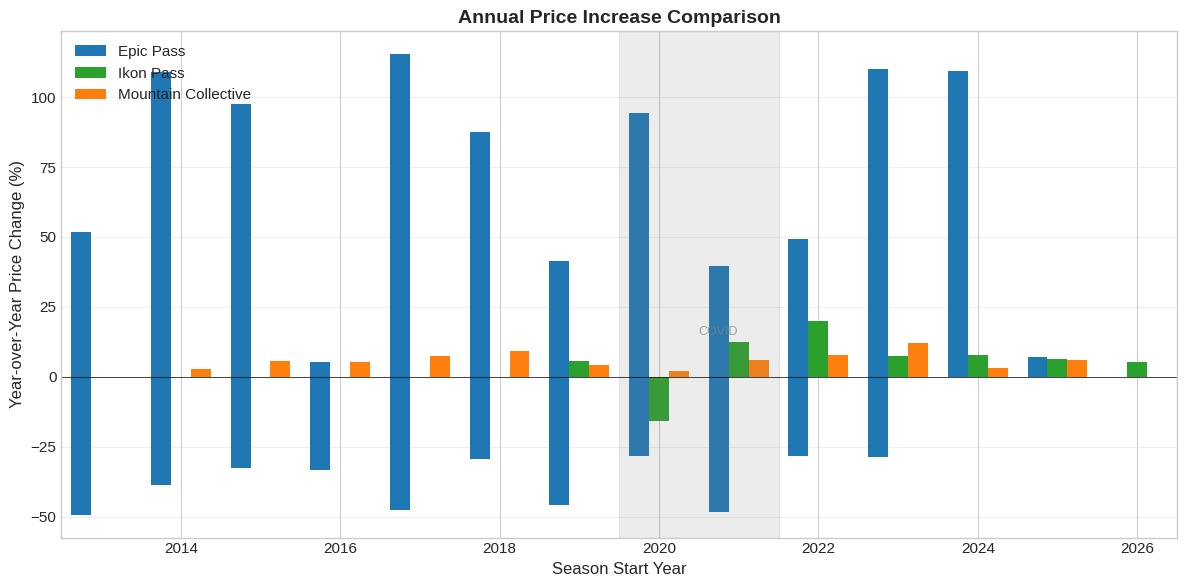

In [9]:
# Visualize YoY percentage changes
fig, ax = plt.subplots(figsize=(12, 6))

epic_yoy = epic_full[epic_full['yoy_pct'].notna()][['season_start_year', 'yoy_pct']]
ikon_yoy = ikon_full[ikon_full['yoy_pct'].notna()][['season_start_year', 'yoy_pct']]
mc_yoy = mc_full[mc_full['yoy_pct'].notna()][['season_start_year', 'yoy_pct']]

width = 0.25
x_epic = epic_yoy['season_start_year'].values
x_ikon = ikon_yoy['season_start_year'].values
x_mc = mc_yoy['season_start_year'].values

ax.bar(x_epic - width, epic_yoy['yoy_pct'].values, width, label='Epic Pass', color='#1f77b4')
ax.bar(x_ikon, ikon_yoy['yoy_pct'].values, width, label='Ikon Pass', color='#2ca02c')
ax.bar(x_mc + width, mc_yoy['yoy_pct'].values, width, label='Mountain Collective', color='#ff7f0e')

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axvspan(2019.5, 2021.5, alpha=0.15, color='gray')
ax.annotate('COVID', xy=(2020.5, 15), fontsize=9, color='gray', alpha=0.7)

ax.set_xlabel('Season Start Year', fontsize=12)
ax.set_ylabel('Year-over-Year Price Change (%)', fontsize=12)
ax.set_title('Annual Price Increase Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.set_xlim(2012.5, 2026.5)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('yoy_price_changes.png', dpi=150, bbox_inches='tight')
plt.show()

## Price Tier Analysis

In [10]:
# Analyze child vs adult pricing ratio
child_passes = df[df['age range'].str.contains('Child', na=False)].copy()
child_passes['category'] = child_passes.apply(categorize_pass, axis=1)

# Merge adult and child for same pass
adult_subset = adult_passes[['pass provider', 'pass name', 'season years', 'price_usd', 'category', 'season_start_year']].copy()
adult_subset = adult_subset.rename(columns={'price_usd': 'adult_price'})

child_subset = child_passes[['pass provider', 'pass name', 'season years', 'price_usd', 'category']].copy()
child_subset = child_subset.rename(columns={'price_usd': 'child_price'})

merged = adult_subset.merge(child_subset, on=['pass provider', 'pass name', 'season years', 'category'], how='inner')
merged['child_ratio'] = (merged['child_price'] / merged['adult_price'] * 100).round(1)

print("Child-to-Adult Pass Price Ratio (%):")
print(merged.groupby('category')['child_ratio'].agg(['mean', 'min', 'max']).round(1))

Child-to-Adult Pass Price Ratio (%):
                     mean   min   max
category                             
Aspen Premier        35.9  34.5  36.3
Epic Local           51.1  49.9  53.1
Epic Pass            52.0  50.6  57.0
Ikon Base            44.8  27.6  66.6
Ikon Pass            38.8  24.4  61.1
Ikon Session         64.3  61.3  67.4
Indy Pass            49.2  42.7  56.6
Mountain Collective  31.0  18.7  65.6


In [11]:
# Current pricing comparison (latest season)
latest_season = df['season_start_year'].max()
latest_df = df[df['season_start_year'] == latest_season].copy()
latest_df['category'] = latest_df.apply(categorize_pass, axis=1)

pivot = latest_df.pivot_table(
    values='price_usd', 
    index='category',
    columns='age range',
    aggfunc='first'
).round(0)

print(f"Current Season ({latest_season}-{latest_season+1}) Pricing:")
print(pivot.to_string())

Current Season (2026-2027) Pricing:
age range  Adult  Child (5-12)  Teen (13-22)
category                                    
Ikon Pass   1399           519          1099


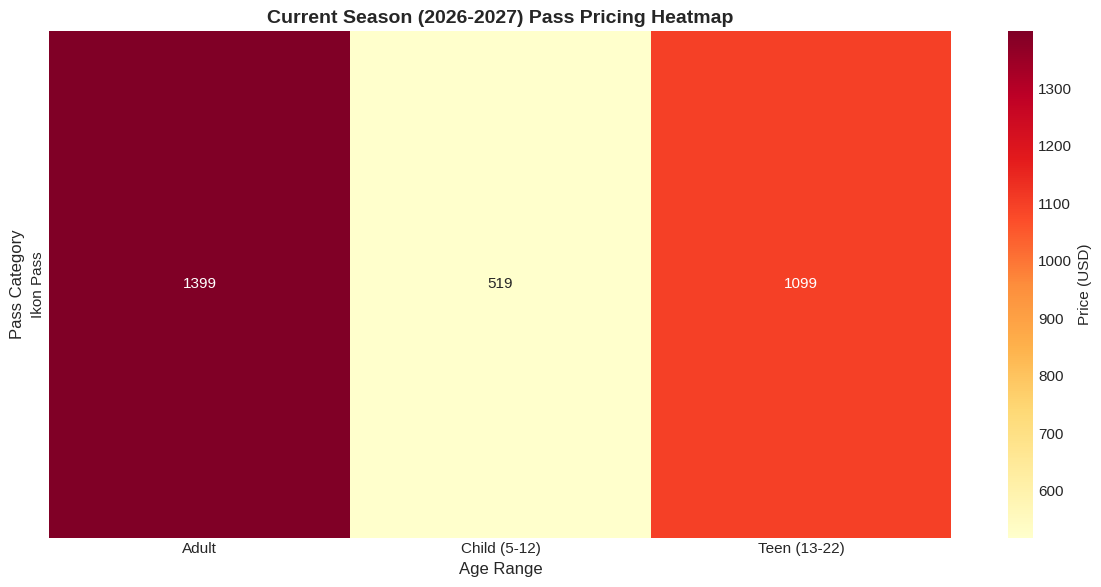

In [12]:
# Heatmap of current pricing
fig, ax = plt.subplots(figsize=(12, 6))

heatmap_data = latest_df.pivot_table(
    values='price_usd',
    index='category',
    columns='age range',
    aggfunc='first'
)

sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', 
            ax=ax, cbar_kws={'label': 'Price (USD)'})
ax.set_title(f'Current Season ({latest_season}-{latest_season+1}) Pass Pricing Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Range', fontsize=12)
ax.set_ylabel('Pass Category', fontsize=12)

plt.tight_layout()
plt.savefig('current_pricing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Value Analysis: Price per Day

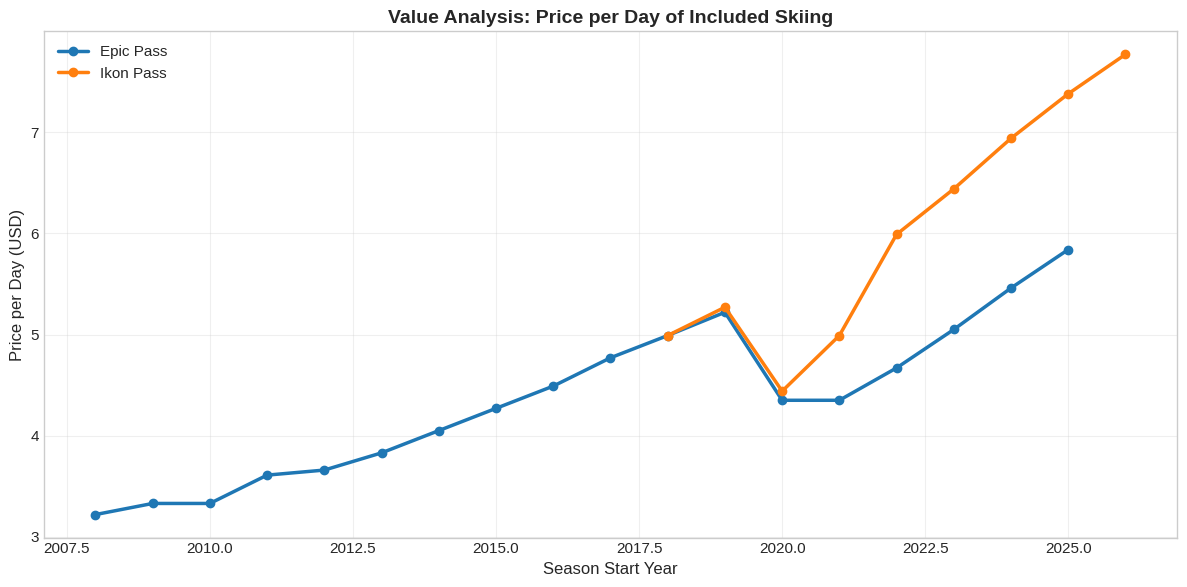

In [13]:
# Estimate days included in passes
days_map = {
    'Epic Pass': 180,
    'Epic Local': 180,
    'Ikon Pass': 180,
    'Ikon Base': 180,
    'Mountain Collective': 4,  # 2 days at each resort, ~20 resorts = 40 days potential
    'Indy Pass': 4,  # 2 days at each resort
    'Epic 7-Day': 7,
    'Epic 4-Day': 4,
    'Ikon Session 4-Day': 4,
}

# Calculate price per included day
df['est_days'] = df['pass name'].map(days_map)
df['price_per_day'] = (df['price_usd'] / df['est_days']).round(2)

adult_with_days = df[(df['age range'] == 'Adult') & (df['est_days'].notna())].copy()
adult_with_days['category'] = adult_with_days.apply(categorize_pass, axis=1)

# Focus on full-season passes
season_passes = adult_with_days[adult_with_days['est_days'] >= 100]

fig, ax = plt.subplots(figsize=(12, 6))
for cat in ['Epic Pass', 'Ikon Pass', 'Aspen Premier', 'Jackson Hole']:
    cat_data = season_passes[season_passes['category'] == cat].sort_values('season_start_year')
    if len(cat_data) > 0:
        ax.plot(cat_data['season_start_year'], cat_data['price_per_day'], 
                marker='o', linewidth=2.5, label=cat)

ax.set_xlabel('Season Start Year', fontsize=12)
ax.set_ylabel('Price per Day (USD)', fontsize=12)
ax.set_title('Value Analysis: Price per Day of Included Skiing', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('price_per_day.png', dpi=150, bbox_inches='tight')
plt.show()

## Market Share Proxy: Price Positioning

In [14]:
# Price gap analysis between Epic and Ikon
epic_prices = adult_passes[adult_passes['category'] == 'Epic Pass'][['season years', 'price_usd', 'season_start_year']].copy()
ikon_prices = adult_passes[adult_passes['category'] == 'Ikon Pass'][['season years', 'price_usd', 'season_start_year']].copy()

comparison = epic_prices.merge(ikon_prices, on=['season years', 'season_start_year'], suffixes=('_epic', '_ikon'))
comparison['price_gap'] = comparison['price_usd_ikon'] - comparison['price_usd_epic']
comparison['premium_pct'] = (comparison['price_gap'] / comparison['price_usd_epic'] * 100).round(1)

print("Epic vs Ikon Price Gap (Ikon - Epic):")
print(comparison[['season years', 'price_usd_epic', 'price_usd_ikon', 'price_gap', 'premium_pct']])

print(f"\nAverage Ikon Premium: ${comparison['price_gap'].mean():.0f} ({comparison['premium_pct'].mean():.1f}%)")

Epic vs Ikon Price Gap (Ikon - Epic):
   season years  price_usd_epic  price_usd_ikon  price_gap  premium_pct
0       2018-19             899             899          0          0.0
1       2019-20             939             949         10          1.1
2       2020-21             783             799         16          2.0
3       2021-22             783             899        116         14.8
4       2022-23             841            1079        238         28.3
5       2023-24             909            1159        250         27.5
6       2024-25             982            1249        267         27.2
7       2025-26            1051            1329        278         26.5
8       2018-19             679             899        220         32.4
9       2019-20             719             949        230         32.0
10      2020-21             563             799        236         41.9
11      2021-22             563             899        336         59.7
12      2022-23           

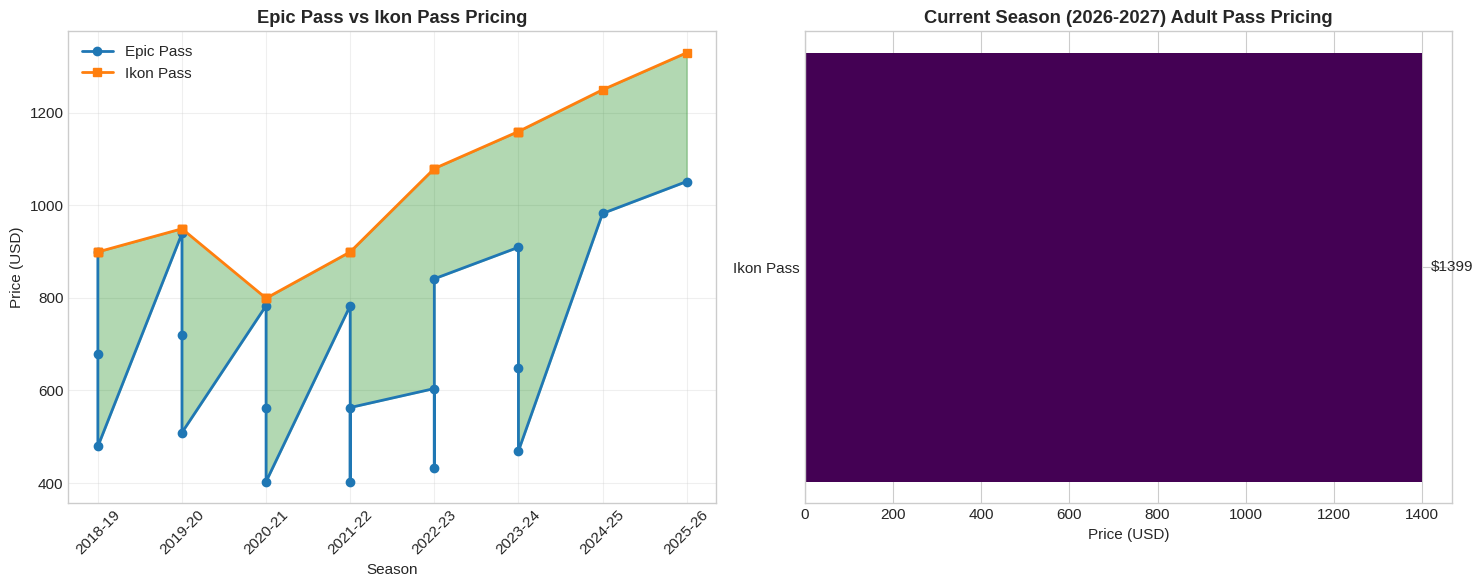

In [15]:
# Visualization of pricing landscape
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left: Epic vs Ikon over time
epic_plot = comparison.sort_values('season_start_year')
ax1.plot(epic_plot['season years'], epic_plot['price_usd_epic'], marker='o', label='Epic Pass', linewidth=2)
ax1.plot(epic_plot['season years'], epic_plot['price_usd_ikon'], marker='s', label='Ikon Pass', linewidth=2)
ax1.fill_between(epic_plot['season years'], epic_plot['price_usd_epic'], epic_plot['price_usd_ikon'], 
                  alpha=0.3, color='green' if epic_plot['price_gap'].iloc[-1] > 0 else 'red')
ax1.set_xlabel('Season')
ax1.set_ylabel('Price (USD)')
ax1.set_title('Epic Pass vs Ikon Pass Pricing', fontweight='bold')
ax1.legend()
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Right: Current market positioning
current = latest_df[latest_df['age range'] == 'Adult'].groupby('category')['price_usd'].max().sort_values(ascending=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(current)))
ax2.barh(current.index, current.values, color=colors)
ax2.set_xlabel('Price (USD)')
ax2.set_title(f'Current Season ({latest_season}-{latest_season+1}) Adult Pass Pricing', fontweight='bold')
for i, v in enumerate(current.values):
    ax2.text(v + 20, i, f'${v}', va='center')

plt.tight_layout()
plt.savefig('market_positioning.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings Summary

In [18]:
# Generate summary statistics
print("="*70)
print("SKI PASS PRICE ANALYSIS: KEY FINDINGS")
print("="*70)

print("\n1. PRICE GROWTH SINCE LAUNCH:")
print("-"*50)
for pass_cat in ['Epic Pass', 'Ikon Pass', 'Mountain Collective']:
    pass_data = adult_passes[adult_passes['category'] == pass_cat].sort_values('season_start_year')
    if len(pass_data) >= 2:
        first = pass_data.iloc[0]
        latest = pass_data.iloc[-1]
        total_increase = ((latest['price_usd'] - first['price_usd']) / first['price_usd'] * 100)
        print(f"   {pass_cat}: {total_increase:.1f}% increase since {first['season years']}")

print("\n2. COVID IMPACT:")
print("-"*50)
epic_2019 = adult_passes[(adult_passes['category'] == 'Epic Pass') & (adult_passes['season_start_year'] == 2019)]['price_usd'].values[0]
epic_2020 = adult_passes[(adult_passes['category'] == 'Epic Pass') & (adult_passes['season_start_year'] == 2020)]['price_usd'].values[0]
print(f"   Epic Pass dropped 20% in 2020-21 season (${epic_2019} -> ${epic_2020})")

print("\n3. CURRENT MARKET (2025-26 Season):")
print("-"*50)
current_prices = latest_df[latest_df['age range'] == 'Adult'].groupby('category')['price_usd'].max()
for cat in ['Epic Pass', 'Ikon Pass', 'Mountain Collective', 'Indy Pass']:
    if cat in current_prices.index:
        print(f"   {cat}: ${current_prices[cat]}")

print("\n4. VALUE PROPOSITION:")
print("-"*50)
#epic_current = adult_passes[(adult_passes['category'] == 'Epic Pass') & (adult_passes['season_start_year'] == latest_season)]['price_usd'].values[0]
#ikon_current = adult_passes[(adult_passes['category'] == 'Ikon Pass') & (adult_passes['season_start_year'] == latest_season)]['price_usd'].values[0]
#indy_current = adult_passes[(adult_passes['category'] == 'Indy Pass') & (adult_passes['season_start_year'] == latest_season)]['price_usd'].values[0]
#print(f"   Ikon is {((ikon_current/epic_current)-1)*100:.0f}% more expensive than Epic")
#print(f"   Indy Pass is {((1 - indy_current/epic_current))*100:.0f}% of Epic Pass price")
#print(f"   Indy = ${indy_current}, Epic = ${epic_current}, Ikon = ${ikon_current}")

SKI PASS PRICE ANALYSIS: KEY FINDINGS

1. PRICE GROWTH SINCE LAUNCH:
--------------------------------------------------
   Epic Pass: 81.5% increase since 2008-09
   Ikon Pass: 55.6% increase since 2018-19
   Mountain Collective: 100.3% increase since 2012-13

2. COVID IMPACT:
--------------------------------------------------
   Epic Pass dropped 20% in 2020-21 season ($939 -> $783)

3. CURRENT MARKET (2025-26 Season):
--------------------------------------------------
   Ikon Pass: $1399

4. VALUE PROPOSITION:
--------------------------------------------------
